Huggingface link - vishalkishore01/transformer_tuning
Github Link - https://github.com/vishalkishore/MLOps-Vishal_Kishore-B23CS1078/tree/assignment_4

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ray
import os
import tempfile
from ray import tune
from ray.air import session
from ray.tune.search.optuna import OptunaSearch
from ray.train import Checkpoint
from ray.tune.schedulers import ASHAScheduler
import torch
import torch.nn as nn
import math
from collections import Counter
import itertools
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from tqdm import tqdm
import nltk
from nltk.translate.bleu_score import sentence_bleu, corpus_bleu, SmoothingFunction
import time

In [47]:
# Load the TSV dataset
df = pd.read_csv('English-Hindi.tsv', sep='\t', header=None, names=["id1", "en", "id2", "hi"])

In [48]:
# Show a sample
df.sample(5)

,id1,en,id2,hi
9534,34182,What's the total population of France?,4078353,फ़्रांस की कुल जनसंख्या कितनी है?
9555,1010322,Strange.,4078415,अजीब बात है।
9033,2011335,I don't want tea.,4061113,मुझे चाय नहीं चाहिए।
12142,9095469,We liked it.,10068395,हमें पसंद आयी।
1335,65723,India was subject to the British Empire.,487678,भारत ब्रिटिज राज के शासन में था।


In [49]:
# Keep only the English and Hindi columns
df = df[["en", "hi"]]

In [50]:
# Drop any rows with missing data
df.dropna(inplace=True)

In [51]:
# Reset index
df.reset_index(drop=True, inplace=True)

In [52]:
# Preview cleaned data
df.head()

,en,hi
0,Muiriel is 20 now.,म्यूरियल अब बीस साल की हो गई है।
1,Muiriel is 20 now.,म्यूरियल अब बीस साल की है।
2,Education in this world disappoints me.,मैं इस दुनिया में शिक्षा पर बहुत निराश हूँ।
3,That won't happen.,वैसा नहीं होगा।
4,I miss you.,मुझें तुम्हारी याद आ रही है।


In [53]:
# Number of sentence pairs
print("Total pairs:", len(df))

Total pairs: 13186


In [54]:
# Sentence length distributions
df["en_len"] = df["en"].apply(lambda x: len(x.split()))
df["hi_len"] = df["hi"].apply(lambda x: len(x.split()))

In [55]:
print("\nEnglish Sentence Length Stats:")
print(df["en_len"].describe())


English Sentence Length Stats:
count    13186.000000
mean         5.607614
std          2.676713
min          1.000000
25%          4.000000
50%          5.000000
75%          7.000000
max         53.000000
Name: en_len, dtype: float64


In [56]:
print("\nHindi Sentence Length Stats:")
print(df["hi_len"].describe())


Hindi Sentence Length Stats:
count    13186.000000
mean         6.277719
std          2.999823
min          1.000000
25%          4.000000
50%          6.000000
75%          8.000000
max         57.000000
Name: hi_len, dtype: float64


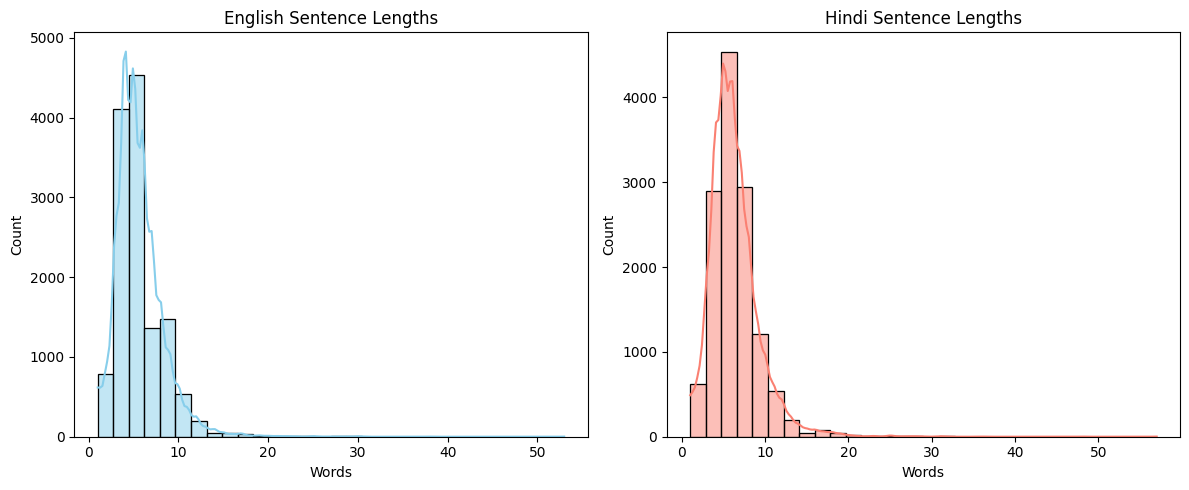

In [57]:
plt.figure(figsize=(12, 5))

# English
plt.subplot(1, 2, 1)
sns.histplot(df["en_len"], bins=30, kde=True, color='skyblue')
plt.title("English Sentence Lengths")
plt.xlabel("Words")

# Hindi
plt.subplot(1, 2, 2)
sns.histplot(df["hi_len"], bins=30, kde=True, color='salmon')
plt.title("Hindi Sentence Lengths")
plt.xlabel("Words")

plt.tight_layout()
plt.show()

In [58]:
for i in range(5):
    print(f"EN: {df.loc[i, 'en']}")
    print(f"HI: {df.loc[i, 'hi']}")
    print("---")

EN: Muiriel is 20 now.
HI: म्यूरियल अब बीस साल की हो गई है।
---
EN: Muiriel is 20 now.
HI: म्यूरियल अब बीस साल की है।
---
EN: Education in this world disappoints me.
HI: मैं इस दुनिया में शिक्षा पर बहुत निराश हूँ।
---
EN: That won't happen.
HI: वैसा नहीं होगा।
---
EN: I miss you.
HI: मुझें तुम्हारी याद आ रही है।
---


In [59]:
def tokenize(sentence):
    return sentence.lower().strip().split()

In [60]:
from collections import Counter
import itertools

In [61]:
class Vocabulary:
    def __init__(self, freq_threshold=2):
        self.freq_threshold = freq_threshold
        self.itos = {0: "<pad>", 1: "<sos>", 2: "<eos>", 3: "<unk>"}
        self.stoi = {"<pad>": 0, "<sos>": 1, "<eos>": 2, "<unk>": 3}
        self.idx = 4

    def build_vocab(self, sentence_list):
        frequencies = Counter()
        for sentence in sentence_list:
            for word in self.tokenize(sentence):
                frequencies[word] += 1

        for word, freq in frequencies.items():
            if freq >= self.freq_threshold:
                self.stoi[word] = self.idx
                self.itos[self.idx] = word
                self.idx += 1

    def tokenize(self, sentence):
        return sentence.lower().strip().split()

    def numericalize(self, sentence):
        tokens = self.tokenize(sentence)
        return [self.stoi.get(token, self.stoi["<unk>"]) for token in tokens]

    def __len__(self):
        return len(self.stoi)

    def __getitem__(self, token):
        return self.stoi.get(token, self.stoi["<unk>"])

In [62]:
# Create vocab instances
en_vocab = Vocabulary(freq_threshold=2)
hi_vocab = Vocabulary(freq_threshold=2)

In [63]:
# Build vocabs
en_vocab.build_vocab(df["en"].tolist())
hi_vocab.build_vocab(df["hi"].tolist())

In [64]:
print(f"English vocab size: {len(en_vocab.stoi)}")
print(f"Hindi vocab size: {len(hi_vocab.stoi)}")

English vocab size: 4117
Hindi vocab size: 4044


In [65]:
def encode_sentence(sentence, vocab, max_len=50):
    tokens = [vocab.stoi["<sos>"]] + vocab.numericalize(sentence)[:max_len-2] + [vocab.stoi["<eos>"]]
    return tokens + [vocab.stoi["<pad>"]] * (max_len - len(tokens))

In [66]:
sample_en = "That won't happen."
sample_hi = "वैसा नहीं होगा।"

In [67]:
print("Encoded English:", encode_sentence(sample_en, en_vocab))
print("Encoded Hindi:", encode_sentence(sample_hi, hi_vocab))

Encoded English: [1, 13, 14, 15, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Encoded Hindi: [1, 21, 22, 23, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [68]:
import torch
import torch.nn as nn
import math

In [69]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

In [70]:
def scaled_dot_product(q, k, v, mask=None):
    d_k = q.size(-1)
    scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)

    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)

    attention = torch.softmax(scores, dim=-1)
    return torch.matmul(attention, v), attention

In [71]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.query_linear = nn.Linear(d_model, d_model)
        self.key_linear = nn.Linear(d_model, d_model)
        self.value_linear = nn.Linear(d_model, d_model)

        self.out_linear = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(0.1)

    def forward(self, q, k, v, mask=None):
        batch_size = q.size(0)

        # Project Q, K, V
        Q = self.query_linear(q)  # [B, T, D]
        K = self.key_linear(k)
        V = self.value_linear(v)

        # Reshape and transpose: [B, T, D] -> [B, H, T, Dk]
        Q = Q.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)  # [B, H, T, Dk]
        K = K.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = V.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)

        # Apply scaled dot-product attention
        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_k ** 0.5)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        attention_weights = torch.softmax(scores, dim=-1)
        attention_output = torch.matmul(self.dropout(attention_weights), V)  # [B, H, T, Dk]

        # Concatenate heads: [B, H, T, Dk] -> [B, T, H * Dk]
        attention_output = attention_output.transpose(1, 2).contiguous() \
                                            .view(batch_size, -1, self.d_model)

        return self.out_linear(attention_output)

In [72]:
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff=2048, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.linear2(self.dropout(self.relu(self.linear1(x))))

In [73]:
class LayerNorm(nn.Module):
    def __init__(self, d_model, eps=1e-6):
        super().__init__()
        self.gamma = nn.Parameter(torch.ones(d_model))
        self.beta = nn.Parameter(torch.zeros(d_model))
        self.eps = eps

    def forward(self, x):
        mean = x.mean(-1, keepdim=True)
        std = x.std(-1, keepdim=True)
        return self.gamma * (x - mean) / (std + self.eps) + self.beta

In [74]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = FeedForward(d_model, d_ff, dropout)
        self.norm1 = LayerNorm(d_model)
        self.norm2 = LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        x = self.norm1(x + self.dropout(self.self_attn(x, x, x, mask)))
        x = self.norm2(x + self.dropout(self.ffn(x)))
        return x

In [75]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.cross_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = FeedForward(d_model, d_ff, dropout)

        self.norm1 = LayerNorm(d_model)
        self.norm2 = LayerNorm(d_model)
        self.norm3 = LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, src_mask=None, tgt_mask=None):
        x = self.norm1(x + self.dropout(self.self_attn(x, x, x, tgt_mask)))
        x = self.norm2(x + self.dropout(self.cross_attn(x, enc_out, enc_out, src_mask)))
        x = self.norm3(x + self.dropout(self.ffn(x)))
        return x

In [76]:
class Encoder(nn.Module):
    def __init__(self, input_vocab_size, d_model, num_layers, num_heads, d_ff, max_len, dropout=0.1):
        super().__init__()
        self.embed = nn.Embedding(input_vocab_size, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len)
        self.layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        x = self.embed(x)
        x = self.pos_enc(x)
        x = self.dropout(x)

        for layer in self.layers:
            x = layer(x, mask)

        return x

In [77]:
class Decoder(nn.Module):
    def __init__(self, target_vocab_size, d_model, num_layers, num_heads, d_ff, max_len, dropout=0.1):
        super().__init__()
        self.embed = nn.Embedding(target_vocab_size, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len)
        self.layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, src_mask=None, tgt_mask=None):
        x = self.embed(x)
        x = self.pos_enc(x)
        x = self.dropout(x)

        for layer in self.layers:
            x = layer(x, enc_out, src_mask, tgt_mask)

        return x

In [78]:
class Transformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model=512, num_layers=6, num_heads=8, d_ff=2048, max_len=100, dropout=0.1):
        super().__init__()
        self.encoder = Encoder(src_vocab_size, d_model, num_layers, num_heads, d_ff, max_len, dropout)
        self.decoder = Decoder(tgt_vocab_size, d_model, num_layers, num_heads, d_ff, max_len, dropout)
        self.fc_out = nn.Linear(d_model, tgt_vocab_size)

    def make_pad_mask(self, seq, pad_idx):
        return (seq != pad_idx).unsqueeze(1).unsqueeze(2)  # [B, 1, 1, T]

    def make_subsequent_mask(self, size):
        return torch.tril(torch.ones((size, size))).bool().to(next(self.parameters()).device)

    def forward(self, src, tgt, src_pad_idx, tgt_pad_idx):
        src_mask = self.make_pad_mask(src, src_pad_idx)
        tgt_pad_mask = self.make_pad_mask(tgt, tgt_pad_idx)
        tgt_sub_mask = self.make_subsequent_mask(tgt.size(1))
        tgt_mask = tgt_pad_mask & tgt_sub_mask  # Combine masks

        enc_out = self.encoder(src, src_mask)
        dec_out = self.decoder(tgt, enc_out, src_mask, tgt_mask)

        out = self.fc_out(dec_out)
        return out

In [79]:
class TranslationDataset(Dataset):
    def __init__(self, df, en_vocab, hi_vocab, max_len=50):
        self.en_sentences = df["en"].tolist()
        self.hi_sentences = df["hi"].tolist()
        self.en_vocab = en_vocab
        self.hi_vocab = hi_vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.en_sentences)

    def __getitem__(self, idx):
        src = encode_sentence(self.en_sentences[idx], self.en_vocab, self.max_len)
        tgt = encode_sentence(self.hi_sentences[idx], self.hi_vocab, self.max_len)
        return torch.tensor(src), torch.tensor(tgt)

In [80]:
def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)
    
    src_batch = torch.stack(src_batch)
    tgt_batch = torch.stack(tgt_batch)

    # Transformer decoder needs: tgt_input (without <eos>) and tgt_output (without <sos>)
    tgt_input = tgt_batch[:, :-1]
    tgt_output = tgt_batch[:, 1:]

    return src_batch, tgt_input, tgt_output

In [81]:
BATCH_SIZE = 60
MAX_LEN = 50

In [82]:
dataset = TranslationDataset(df, en_vocab, hi_vocab, max_len=MAX_LEN)
train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)

In [83]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {DEVICE}")

Using Device: cuda


In [84]:
# Hyperparams
SRC_PAD_IDX = en_vocab["<pad>"]
TGT_PAD_IDX = hi_vocab["<pad>"]
NUM_EPOCHS = 100
D_MODEL = 512

# Ray Tune code

In [85]:
def train_tune(config):

    d_model = 512
    num_heads = config["num_heads"]

    if d_model % num_heads != 0:
        session.report({"loss": float("inf")})
        return

    device = "cuda" if torch.cuda.is_available() else "cpu"

    model = Transformer(
        src_vocab_size=len(en_vocab),
        tgt_vocab_size=len(hi_vocab),
        d_model=d_model,
        num_layers=6,
        num_heads=num_heads,
        d_ff=config["d_ff"],
        max_len=MAX_LEN,
        dropout=config["dropout"]
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"])
    criterion = nn.CrossEntropyLoss(ignore_index=TGT_PAD_IDX)

    tune_loader = DataLoader(dataset,
                             batch_size=config["batch_size"],
                             shuffle=True,
                             collate_fn=collate_fn)

    for epoch in range(20): 
        model.train()
        total_loss = 0

        for src, tgt_input, tgt_output in tune_loader:
            src, tgt_input, tgt_output = src.to(device), tgt_input.to(device), tgt_output.to(device)

            output = model(src, tgt_input, SRC_PAD_IDX, TGT_PAD_IDX)
            loss = criterion(output.view(-1, output.size(-1)), tgt_output.view(-1))

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(tune_loader)

        with tempfile.TemporaryDirectory() as temp_checkpoint_dir:
            checkpoint_path = os.path.join(temp_checkpoint_dir, "model.pth")
            torch.save(model.state_dict(), checkpoint_path)
            
            checkpoint = Checkpoint.from_directory(temp_checkpoint_dir)
            
            # Report metrics and checkpoint to Ray
            session.report({"loss": avg_loss}, checkpoint=checkpoint)


In [86]:
search_space = {
    "batch_size": tune.choice([32, 48, 64, 96]),
    "lr": tune.loguniform(1e-5, 1e-3),
    "num_heads": tune.choice([4, 8, 16]),
    "d_ff": tune.choice([1024, 2048, 4096]),
    "dropout": tune.uniform(0.05, 0.3),
}

scheduler = ASHAScheduler(
    metric="loss",
    mode="min",
    max_t=10,
    grace_period=2,
    reduction_factor=2
)

In [87]:
optuna_search = OptunaSearch(metric="loss", mode="min")

In [88]:
tuner = tune.Tuner(
    tune.with_resources(
        train_tune,
        resources={"gpu": 1} if torch.cuda.is_available() else {"cpu": 1}
    ),
    tune_config=tune.TuneConfig(
        search_alg=optuna_search,
        num_samples=1,
        scheduler=scheduler
    ),
    param_space=search_space,
)

In [89]:
results = tuner.fit()
best_result = results.get_best_result(metric="loss", mode="min")
print(f"Best config: {best_result.config}")

(raylet) [2026-03-18 14:04:36,670 E 721157 721182] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2026-03-18_14-04-25_290367_699152 is over 95% full, available space: 33.0283 GB; capacity: 912.81 GB. Object creation will fail if spilling is required.
(raylet) [2026-03-18 14:04:46,676 E 721157 721182] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2026-03-18_14-04-25_290367_699152 is over 95% full, available space: 33.0278 GB; capacity: 912.81 GB. Object creation will fail if spilling is required.
(raylet) [2026-03-18 14:04:56,682 E 721157 721182] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2026-03-18_14-04-25_290367_699152 is over 95% full, available space: 33.0273 GB; capacity: 912.81 GB. Object creation will fail if spilling is required.
(raylet) [2026-03-18 14:05:06,687 E 721157 721182] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2026-03-18_14-04-25_290367_699152 is over 95% full, available space: 33.0265 GB; capacity: 912.81 GB. Object creation wil

Best config: {'batch_size': 32, 'lr': 0.00018280088579040787, 'num_heads': 8, 'd_ff': 2048, 'dropout': 0.25775259930453936}


In [90]:
best_config = best_result.config

In [91]:
# Hyperparams
SRC_PAD_IDX = en_vocab["<pad>"]
TGT_PAD_IDX = hi_vocab["<pad>"]
NUM_EPOCHS = 1
D_MODEL = 512

model = Transformer(
    src_vocab_size=len(en_vocab),
    tgt_vocab_size=len(hi_vocab),
    d_model=512,
    num_layers=6,
    num_heads=best_config["num_heads"],
    d_ff=best_config["d_ff"],
    max_len=MAX_LEN,
    dropout=best_config["dropout"]
).to(DEVICE)

print("Tuning complete. Best config found and model initialized.")

(train_tune pid=724857) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_tune_2026-03-18_14-04-25/train_tune_c6bb1101_1_batch_size=32,d_ff=2048,dropout=0.2578,lr=0.0002,num_heads=8_2026-03-18_14-04-28/checkpoint_000009)


Tuning complete. Best config found and model initialized.


In [92]:
criterion = nn.CrossEntropyLoss(ignore_index=TGT_PAD_IDX)
optimizer = optim.Adam(model.parameters(), lr=best_config["lr"])

In [93]:
def save_checkpoint(epoch, model, optimizer, loss, path="checkpoint.pt"):
    torch.save({
        'epoch': epoch,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'loss': loss
    }, path)

    print(f"Checkpoint saved at epoch {epoch}, loss {loss:.4f}.")

In [94]:
import torch

def load_checkpoint(model, optimizer, path="checkpoint.pt"):
    if torch.cuda.is_available() and path is not None and os.path.exists(path):
        checkpoint = torch.load(path)
    elif path is not None and os.path.exists(path):
        checkpoint = torch.load(path, map_location=torch.device('cpu'))
    else:
        print(f"No checkpoint found at {path}. Starting from scratch.")
        return 0

    model.load_state_dict(checkpoint['model_state'])
    optimizer.load_state_dict(checkpoint['optimizer_state'])

    epoch = checkpoint['epoch']
    loss = checkpoint['loss']

    print(f"✅ Loaded checkpoint from epoch {epoch} with loss {loss:.4f}")
    
    return epoch

In [95]:
def train(model, train_loader, optimizer, criterion, start_epoch=0, num_epochs=NUM_EPOCHS, checkpoint_path="checkpoint.pt"):
    for epoch in range(start_epoch, num_epochs):
        model.train()
        epoch_loss = 0
        loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}]")

        for src, tgt_input, tgt_output in loop:
            src, tgt_input, tgt_output = src.to(DEVICE), tgt_input.to(DEVICE), tgt_output.to(DEVICE)

            output = model(src, tgt_input, SRC_PAD_IDX, TGT_PAD_IDX)
            output = output.view(-1, output.shape[-1])
            tgt_output = tgt_output.view(-1)

            loss = criterion(output, tgt_output)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            loop.set_postfix(loss=loss.item())

        # Save checkpoint at end of each epoch
        save_checkpoint(epoch+1, model, optimizer, epoch_loss / len(train_loader), checkpoint_path)

In [96]:
start_epoch = load_checkpoint(model, optimizer)

No checkpoint found at checkpoint.pt. Starting from scratch.


In [97]:
%%time
train(model, train_loader, optimizer, criterion, start_epoch=start_epoch)

Epoch [1/1]: 100%|██████████| 220/220 [01:11<00:00,  3.10it/s, loss=4.66]


Checkpoint saved at epoch 1, loss 5.3294.
CPU times: user 2min 2s, sys: 24.1 s, total: 2min 26s
Wall time: 1min 11s


In [98]:
def translate_sentence(model, sentence, en_vocab, hi_vocab, max_len=50):
    model.eval()
    tokens = encode_sentence(sentence, en_vocab, max_len=max_len)
    src_tensor = torch.tensor(tokens).unsqueeze(0).to(DEVICE)

    tgt_tokens = [hi_vocab["<sos>"]]
    for _ in range(max_len):
        tgt_tensor = torch.tensor(tgt_tokens).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            output = model(src_tensor, tgt_tensor, SRC_PAD_IDX, TGT_PAD_IDX)
        next_token = output[0, -1].argmax().item()
        tgt_tokens.append(next_token)
        if next_token == hi_vocab["<eos>"]:
            break

    translated = [hi_vocab.itos[idx] for idx in tgt_tokens[1:-1]]
    return ' '.join(translated)

In [99]:
example_sentences = [
    "I love you.",
    "What is your name?",
    "How are you?",
    "The weather is nice today.",
    "She is a good teacher."
]

In [100]:
for sentence in example_sentences:
    translation = translate_sentence(model, sentence, en_vocab, hi_vocab)
    print(f"\n🗣 English: {sentence}")
    print(f"🇮🇳 Hindi: {translation}")


🗣 English: I love you.
🇮🇳 Hindi: मैं तुम्हें नहीं हूँ।

🗣 English: What is your name?
🇮🇳 Hindi: क्या क्या क्या क्या क्या क्या है?

🗣 English: How are you?
🇮🇳 Hindi: क्या तुम क्या है?

🗣 English: The weather is nice today.
🇮🇳 Hindi: वे मेरी है।

🗣 English: She is a good teacher.
🇮🇳 Hindi: वह एक एक एक है।


In [101]:
import nltk
from nltk.translate.bleu_score import sentence_bleu, corpus_bleu, SmoothingFunction

In [102]:
smoothie = SmoothingFunction().method4

In [103]:
def evaluate_bleu_nltk(model, dataset, en_vocab, hi_vocab, max_len=50):
    references = []
    hypotheses = []

    for en_sentence, hi_sentence in dataset:
        pred = translate_sentence(model, en_sentence, en_vocab, hi_vocab, max_len)
        pred_tokens = pred.split()
        ref_tokens = hi_sentence.split()

        references.append([ref_tokens])   # list of reference lists
        hypotheses.append(pred_tokens)    # list of predicted tokens

    score = corpus_bleu(references, hypotheses, smoothing_function=smoothie)
    print(f"🌐 BLEU Score (NLTK): {score * 100:.2f}")
    return score

In [104]:
val_dataset = [
    ("I love you.", "मैं तुमसे प्यार करता हूँ।"),
    ("How are you?", "आप कैसे हैं?"),
    ("You should sleep.", "आपको सोना चाहिए।"),
    ("Maybe Tom doesn't love you.", "टॉम शायद तुमसे प्यार नहीं करता है।"),
    ("Let me tell Tom.","मुझे टॉम को बताने दीजिए।")
]

In [105]:
evaluate_bleu_nltk(model, val_dataset, en_vocab, hi_vocab)

🌐 BLEU Score (NLTK): 10.09


0.10088113178460024

In [ ]:
# Save the model weights
torch.save(model.state_dict(), "transformer_translation_final.pth")

# Save vocab mappings (example using pickle)
import pickle
with open("en_vocab.pkl", "wb") as f:
    pickle.dump(en_vocab, f)

with open("hi_vocab.pkl", "wb") as f:
    pickle.dump(hi_vocab, f)

print("✅ Model and vocabs saved.")

✅ Model and vocabs saved.


(raylet) [2026-03-18 14:19:37,099 E 721157 721182] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2026-03-18_14-04-25_290367_699152 is over 95% full, available space: 28.8731 GB; capacity: 912.81 GB. Object creation will fail if spilling is required.
(raylet) [2026-03-18 14:19:47,105 E 721157 721182] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2026-03-18_14-04-25_290367_699152 is over 95% full, available space: 28.7316 GB; capacity: 912.81 GB. Object creation will fail if spilling is required.
(raylet) [2026-03-18 14:19:57,110 E 721157 721182] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2026-03-18_14-04-25_290367_699152 is over 95% full, available space: 28.7311 GB; capacity: 912.81 GB. Object creation will fail if spilling is required.
(raylet) [2026-03-18 14:20:07,116 E 721157 721182] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2026-03-18_14-04-25_290367_699152 is over 95% full, available space: 28.7299 GB; capacity: 912.81 GB. Object creation wil